<a href="https://colab.research.google.com/github/gravity102424/ESAA/blob/main/ESAA_OB_week11_2_Performance_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 8.3 하이퍼파라미터를 이용한 성능 최적화

## 8.3.1 배치 정규화를 이용한 성능 최적화

## 정규화

정규화(normalization)는 데이터 범위를 사용자가 원하는 범위로 제한하는 것을 의미한다. 예를 들어 이미지 데이터는 픽셀 정보로 0~255 사이의 값을 갖는데, 이를 255로 나누면 0~1.0 사이의 값을 갖게 된다.

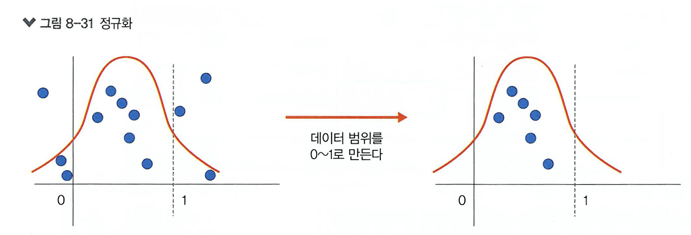

정규화는 각 특성 범위를 조정한다는 의미로 특성 스케일링이라고도 한다. 스케일 조정을 위해 MinMaxScaler() 기법을 사용하므로 수식은 다음과 같다.

$\frac{x-x_{min}}{x
_{max}-x_{min}}$

## 규제화

규제화(regularization)는 모델 복잡도를 줄이기 위해 제약을 두는 방법이다. 이때 제약은 데이터가 네트워크에 들어가기 전에 필터를 적용한 것이라고 생각하면 된다. 예를 들어 다음 왼쪽 그림은 필터가 적용되지 않을 경우 모든 데이터가 네트워크에 투입되지만, 오른쪽 그림은 필터로 걸러진 데이터만 네트워크에 투입되어 빠르고 정확한 결과를 얻을 수 있다.

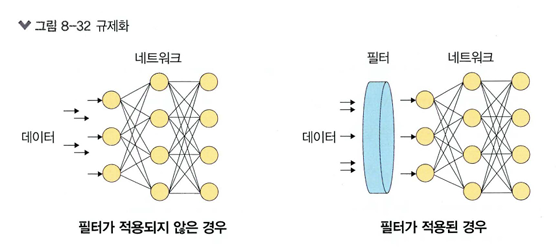

규제를 이용하여 모델 복잡도를 줄이는 방법은 다음과 같다.

* 드롭아웃
* 조기 종료

## 표준화

표준화(standardization)는 기존 데이터를 평균은 0, 표준편차는 1인 형태의 데이터로 만드는 방법이다. 다른 표현으로 표준화 스칼라 혹은 z-스코어 정규화라고도 한다.

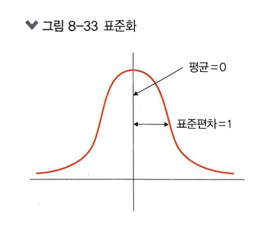

평균을 기준으로 얼마나 떨어져 있는지 살펴볼 때 사용한다. 보통 데이터 분포가 가우시안 분포를 따를 때 유용한 방법으로 다음 수식을 사용한다.

$\frac{x-m}{\sigma }$

($\sigma$: 표준편차, $x$: 관측 값(입력 값), $m$: 평균)

## 배치 정규화

배치 정규화는 2015년“Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift" 논문에 설명되어 있는 기법으로， 데이터 분포가 안정되어 학습 속도를 높일 수 있다.

배치 정규화는 기울기 소멸이나 기울기 폭발과 같은 문제를 해결하기 위한 방법이다. 일반적으로 기울기 소멸이나 폭발 문제를 해결하기 위해 손실 함수로 렐루(ReLU)를 사용하거나 초깃값 튜닝, 학습률 등을 조정한다.

## 기울기 소멸과 기울기 폭발

* 기울기 소멸: 오차 정보를 역전파시키는 과정에서 기울기가 급격히 0에 가까워져 학습이 되지 않는 현상이다.

* 기울기 폭발: 학습 과정에서 기울기가 급격히 커지는 현상이다.

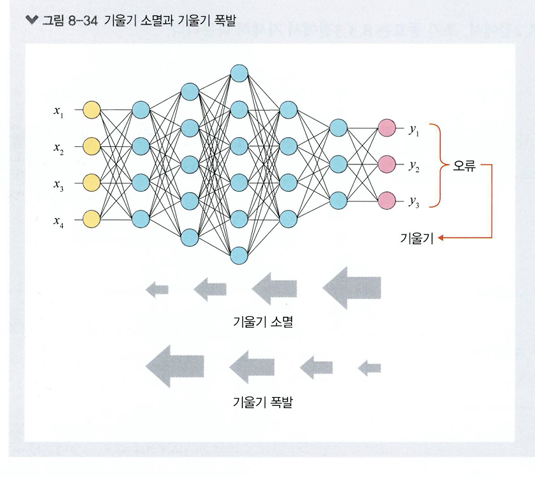

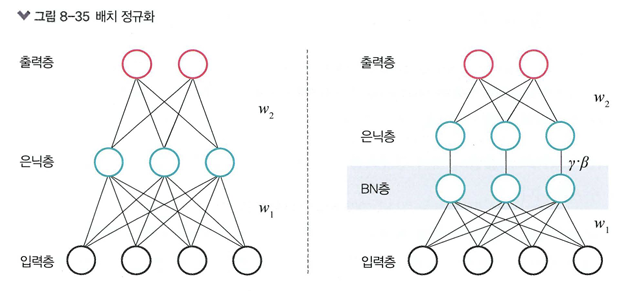

배치 정규화가 소개된 논문에 따르면 기울기 소멸과 폭발 원인은 내부 공변량 변화(internal covariance shift)때문인데, 이것은 네트워크의 각 층마다 활성화 함수가 적용되면서 입력 값들의 분포가 계속 바뀌는 현상을 의미한다. 따라서 분산된 분포를 정규분포로 만들기 위해 표준화와 유사한 방식을 미니 배치에 적용하여 평균은 0으로, 표준편차는 1로 유지하도록 하며 수식은 다음과 같다.

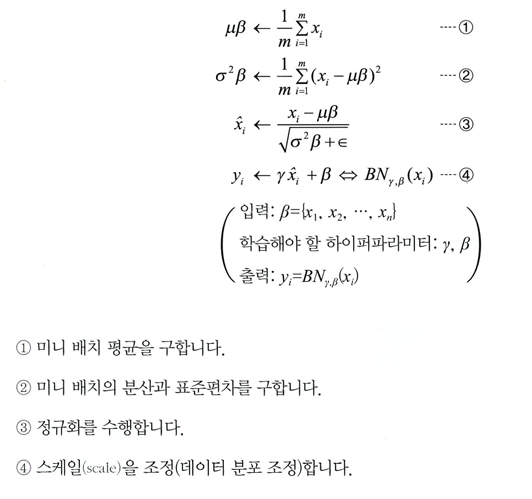

따라서 매 단계마다 활성화 함수를 거치면서 데이터셋 분포가 일정해지기 때문에 속도를 향상시킬 수 있지만 다음과 같은 단점도 있다.

첫째, 배치 크기가 작을 때는 정규화 값이 기존 값과 다른 방향으로 훈련될 수 있다. 예를 들어 분산이 0이면 정규화 자체가 안 되는 경우가 생길 수 있다.

둘째， RNN은 네트워크 계층별로 미니 정규화를 적용해야 하기 때문에 모델이 더 복잡해지면서
비효율적일 수 있다.

따라서 이러한 문제들을 해결하기 위한 가중치 수정, 네트워크 구성 변경 등을 수행하지만， 무엇보다 중요한 것은 배치 정규화를 적용하면 적용하지 않았을 때보다 성능이 좋아지기 때문에 많이 사용된다.

## 드롭아웃을 이용한 성능 최적화

과적합은 훈련 데이터셋을 과하게 학습하는 것을 의미한다. 그렇다면 과하게 훈련 데이터셋을 학습하는 것이 왜 문제일까? 일반적으로  훈련 데이터셋은 실제 데이터셋의 부분 집합이므로 훈
련 데이터셋에 대해서는 오류가 감소하지만， 테스트 데이터셋에 대해서는 오류가 증가한다. 즉，
훈련 데이터셋에 대해 훈련을 계속한다면 오류는 줄어들지만 테스트 데이터셋에 대한 오류는 어
느 순간부터 증가하는데 이러한 모델을 과적합되어 있다고 한다.

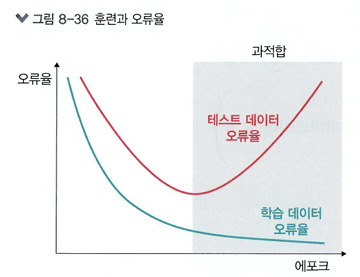

드롭아웃이란 훈련할 때 일정 비율의 뉴런만 사용하고, 나머지 뉴런에 해당하는 가중치는 업데이트하지 않는 방법이다. 물론 매 단계마다 사용하지 않는 뉴런을 바꾸어 가며 훈련시킨다. 즉, 드롭아웃은 노드를 임의로 끄면서 학습하는 방법으로, 은닉층에 배치된 노드 중 일부를 임의로 끄면서 학습한다. 꺼진 노드는 신호를 전달하지 않으므로 지나친 학습을 방지하는 효과가 생긴다.

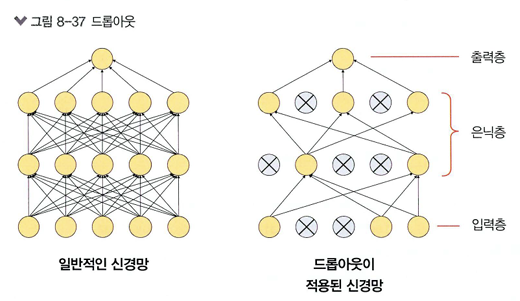

그림 8-37의 왼쪽은 일반적인 신경망이고, 오른쪽은 드롭아웃이 적용된 신경망의 모습이다.
일부 노드들은 비활성화되고 남은 노드들로 신호가 연결되는 신경망 형태를 띠고 있다. 어떤
노드를 비활성화할지는 학습할 때마다 무작위로 선정되며， 테스트 데이터로 평가할 때는 노드들
을 모두 사용하여 출력하되 노드 삭제 비율(드롭이웃 비율)을 곱해서 성능을 평가한다.
드롭아웃을 사용하면 훈련 시간이 길어지는 단점이 있지만, 모델 성능을 향상하기 위해 상당히 자주 쓰는 방법이다.

그럼 배치 정규화와 드롭아웃에 대한 파이토치 예제를 알아보겠다. 여기에서 시용되는 데이
터셋은 파이토치 torchvision. datasets에서 제공하는 FashionMNIST 데이터셋이다.

In [4]:
# 라이브러리 호출

import torch
import matplotlib.pyplot as plt
import numpy as np

import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim

In [5]:
# 데이터셋 내려받기

trainset = torchvision.datasets.FashionMNIST(
    root='../chap08/data/', train=True,
    download=True,
    transform=transforms.ToTensor()
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.6MB/s]


In [6]:
# 데이터셋을 메모리로 가져오기

batch_size = 4
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

In [7]:
# 데이터셋 분리

dataiter = iter(trainloader)
images, labels = next(dataiter)

print(images.shape)
print(images[0].shape)
print(labels[0].item())

torch.Size([4, 1, 28, 28])
torch.Size([1, 28, 28])
9


In [8]:
# 이미지 데이터를 출력하기 위한 전처리

def imshow(img, title):
  plt.figure(figsize=(batch_size*4,4))
  plt.axis('off')
  plt.imshow(np.transpose(img,(1,2,0)))
  plt.title(title)
  plt.show()

In [9]:
# 이미지 데이터 출력 함수

def show_batch_images(dataloader):
  images, labels = next(iter(dataloader))

  img = torchvision.utils.make_grid(images)
  imshow(img, title=[str(x.item()) for x in labels])

  return images, labels

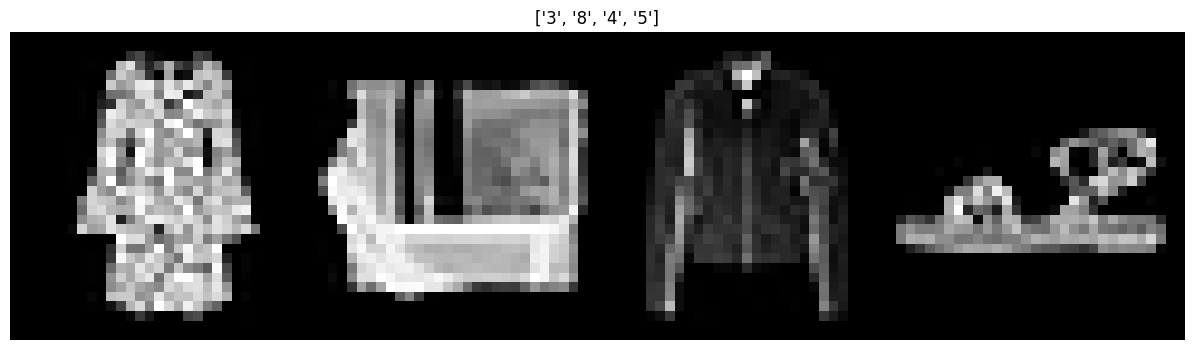

In [10]:
# 이미지 출력

images, labels = show_batch_images(trainloader)

In [11]:
# 배치 정규화가 적용되지 않은 네트워크

class NormalNet(nn.Module):
  def __init__(self):
    super(NormalNet, self).__init__()
    self.classifier = nn.Sequential(
        nn.Linear(784, 48),
        nn.ReLU(),
        nn.Linear(48, 24),
        nn.ReLU(),
        nn.Linear(24, 10)
    )

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.classifier(x)
    return x

In [12]:
# 배치 정규화가 포함된 네트워크

class BNNet(nn.Module):
  def __init__(self):
    super(BNNet, self).__init__()
    self.classifier = nn.Sequential(
        nn.Linear(784, 48),
        nn.BatchNorm1d(48), # 1
        nn.ReLU(),
        nn.Linear(48, 24),
        nn.BatchNorm1d(24),
        nn.ReLU(),
        nn.Linear(24, 10)
    )

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.classifier(x)
    return x

1. 배치 정규화가 적용되는 부분이다. BatchNorm1d에서 사용되는 파라미터는 특성 개수로 이전 계층의 출력 채널이 된다.

배치 정규화를 사용하는 이유는 은닉층에서 학습이 진행될 때마다 입력 분포가 변하면서 가중치가 엉뚱한 방향으로 갱신되는 문제가 종종 발생하기 때문이다. 즉, 신경망의 층이 깊어질수록 학습할 때 가정했던 입력 분포가 변화하여 엉뚱한 학습이 진행될 수 있는데 배치 정규화 적용해서 입력 분포를 고르게 맞추어 줄 수 있다.

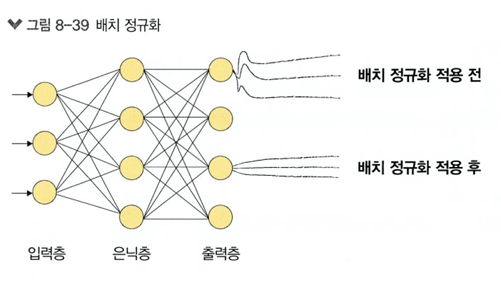

참고로 배치 정규화는 다음과 같은 위치에 놓여야 한다.


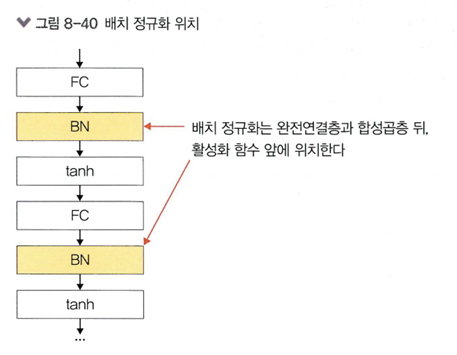

In [13]:
# 배치 정규화가 적용되지 않은 모델 선언

model = NormalNet()
print(model)

NormalNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [14]:
# 배치 정규화가 적용된 모델 선언

model_bn = BNNet()
print(model_bn)

BNNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=24, bias=True)
    (4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=24, out_features=10, bias=True)
  )
)


데이터로더를 이용하여 앞에서 내려받았던 데이터셋을 메모리로 불러올 준비를 한다. 참고로 앞에서도 메모리로 불러오는 부분을 진행했다. 그때는 이미지 출력을 위한 용도로 배치 크기를 4로 설정했지만， 이번에 메모리로 불러오는 것은 학습을 위한 용도로 배치 크기를 512로 지정한다.

In [15]:
# 데이터셋 메모리로 불러오기

batch_size = 512
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,shuffle=True)

In [16]:
# 옵티마이저, 손실 함수 지정

loss_fn = nn.CrossEntropyLoss()
opt = optim.SGD(model.parameters(), lr = 0.01)
opt_bn = optim.SGD(model_bn.parameters(), lr = 0.01)

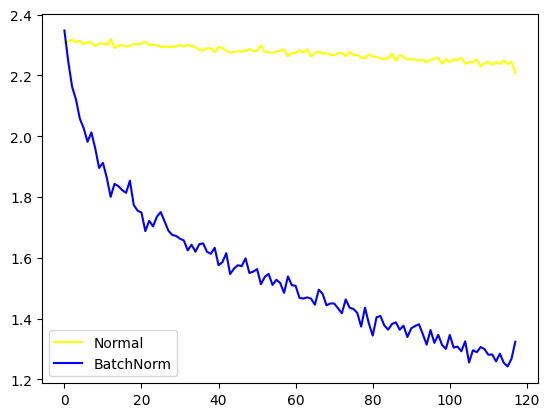

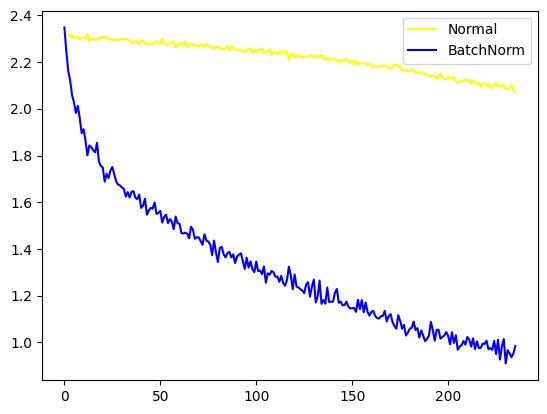

In [17]:
# 모델 학습

loss_arr = []
loss_bn_arr = []
max_epochs = 2

for epoch in range(max_epochs):
  for i, data in enumerate(trainloader, 0):
    inputs, labels = data
    opt.zero_grad()
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    loss.backward()
    opt.step()

    opt_bn.zero_grad()
    outputs_bn = model_bn(inputs)
    loss_bn = loss_fn(outputs_bn, labels)
    loss_bn.backward()
    opt_bn.step()

    loss_arr.append(loss.item())
    loss_bn_arr.append(loss_bn.item())

  plt.plot(loss_arr, 'yellow', label='Normal')
  plt.plot(loss_bn_arr, 'blue', label='BatchNorm')
  plt.legend()
  plt.show()

다음 그림들은 모댈 학습 결과(오차 정보)를 보여 준다. 모델 학습 결과는 배치 정규화가 적용된 모델(아래 그림의 파란색 그래프)과 적용되지 않은 모댈(아래 그림의 노란색 그래프)을 그래프로 출력한다.


배치 정규화가 적용된 모델과 적용되지 않은 모벨의 오차에 대한 그래프 결과가 어떤가? 둘 다 시간이 흐를수록 오차가 줄어드는 것을 확인할 수 있다. 하지만 오차가 줄어드는 범위 및 값의 차이는 명백하다. 배치 정규화가 적용된 모델의 경우 더 낮은 값으로 안정적인 범위 내에서 줄어들고 있는 것을 확인할 수 있다. 즉, 다른 말로 표현하면 배치 정규화가 적용된 모댈은 에포크가 진행될수록 오차도 줄어들면서 안정적인 학습을 하고 있다고 할 수 있다.

배치 정규화가 성능에 어떤 영향을 미치는지 확인했다면 이번에는 드롭아웃에 대해 살펴보겠다.

드롭이웃을 알아보기에 앞서 훈련과 테스트 데이터셋이 어떻게 분포하는지 알아보겠다.

In [18]:
# 데이터셋의 분포를 출력하기 위한 전처리

N = 50
noise = 0.3

x_train = torch.unsqueeze(torch.linspace(-1,1,N),1)
y_train = x_train + noise * torch.normal(torch.zeros(N,1), torch.ones(N,1))

x_test = torch.unsqueeze(torch.linspace(-1 , 1, N), 1)
y_test = x_test + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))

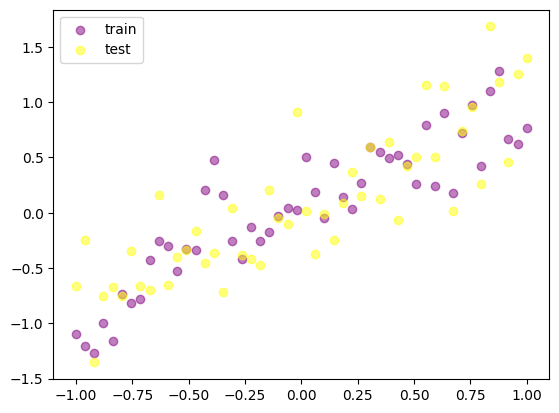

In [19]:
# 데이터 분포를 그래프로 출력

plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c='purple',
            alpha=0.5, label='train')
plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c='yellow',
            alpha=0.5, label='test')
plt.legend()
plt.show()

In [20]:
# 드롭아웃을 위한 모델 생성

N_h = 100
model = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, 1),
)

model_dropout = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, 1),
)

In [21]:
# 옵티마이저와 손실 함수 지정

opt = torch.optim.Adam(model.parameters(), lr = 0.01)
opt_dropout = torch.optim.Adam(model_dropout.parameters(), lr = 0.01)
loss_fn = torch.nn.MSELoss()

/tmp/ipykernel_1434/2452511495.py:37: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.title('Epoch %d, Loss=%0.4f, Loss with dropout=%0.4f' %


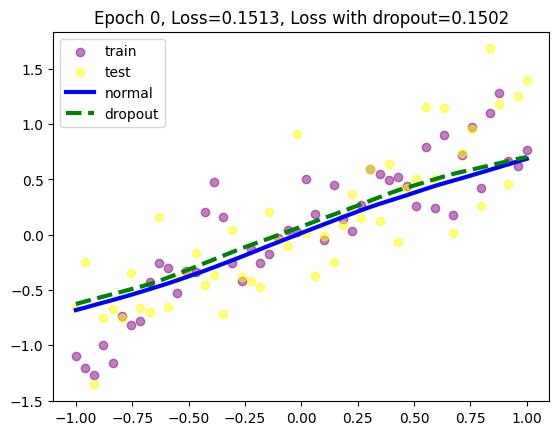

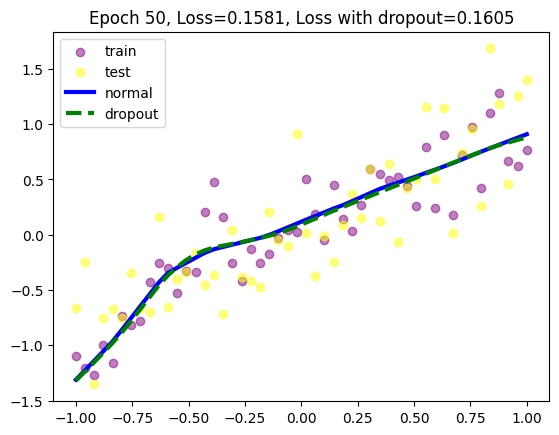

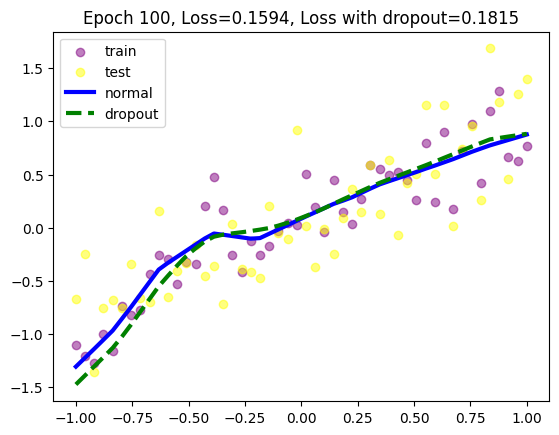

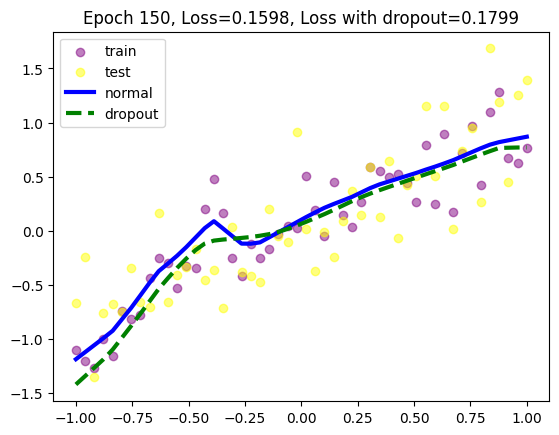

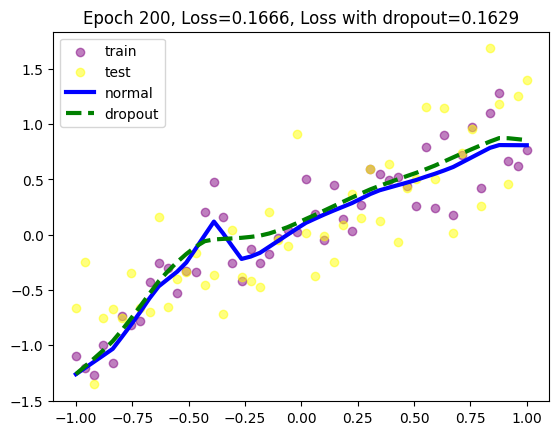

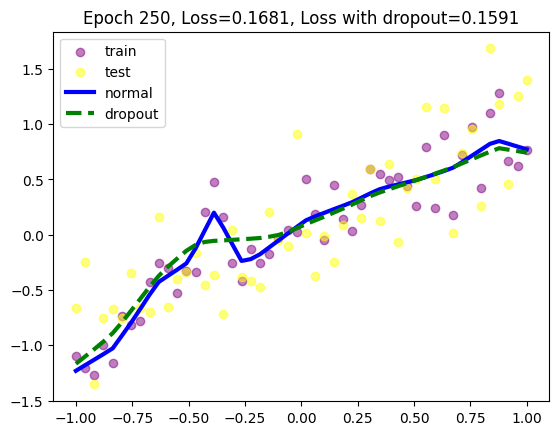

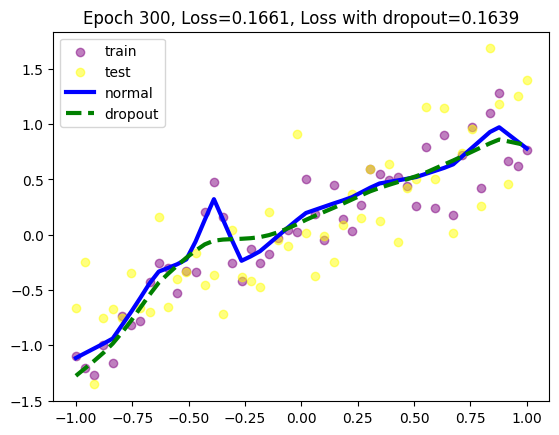

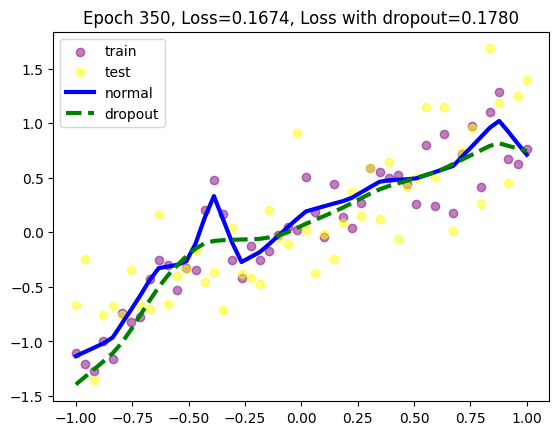

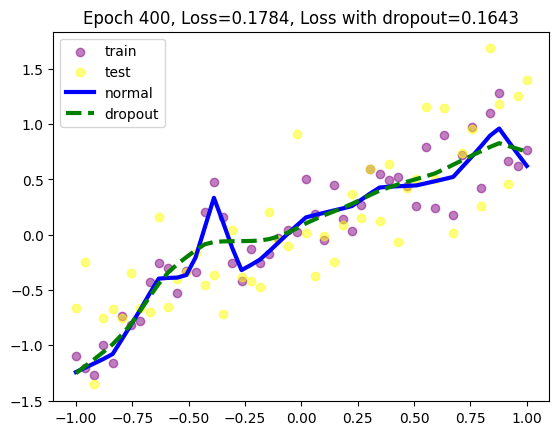

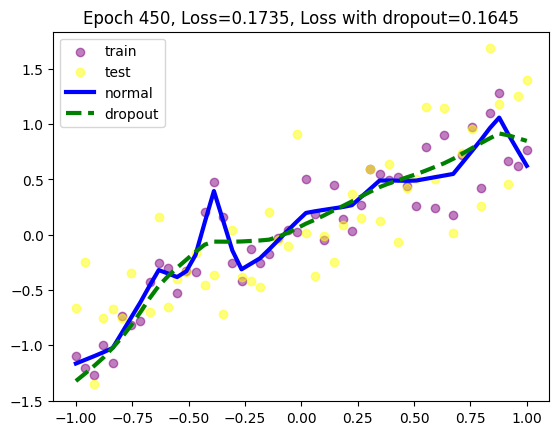

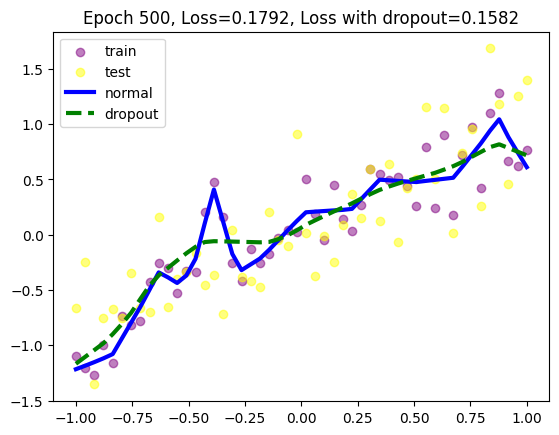

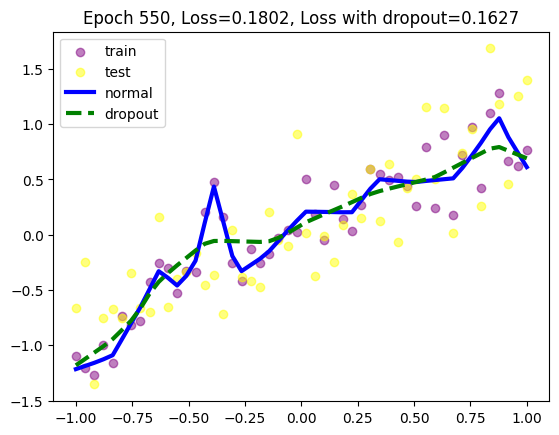

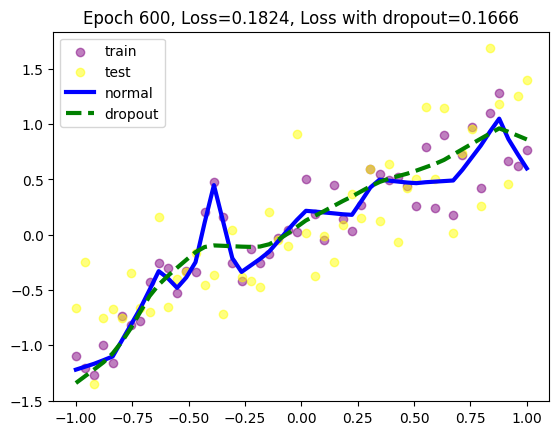

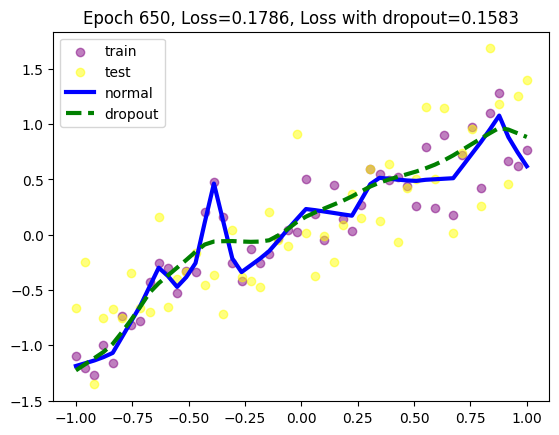

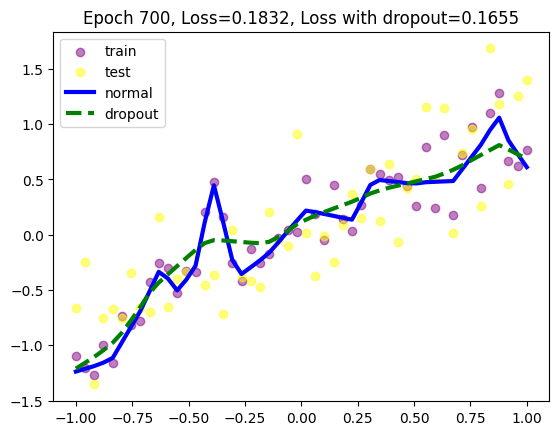

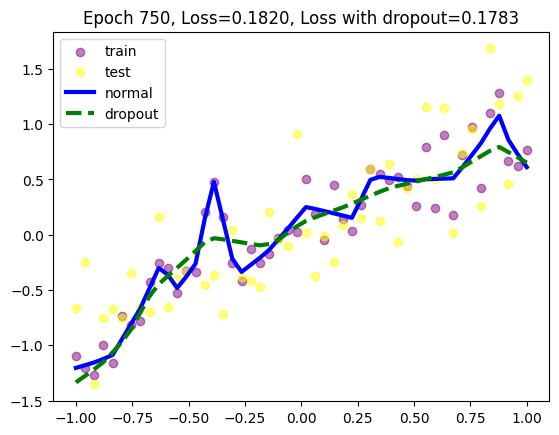

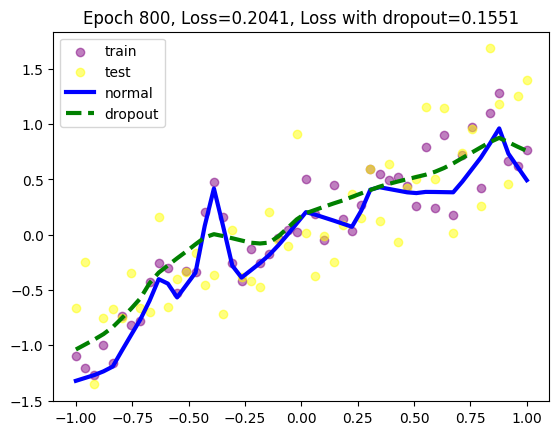

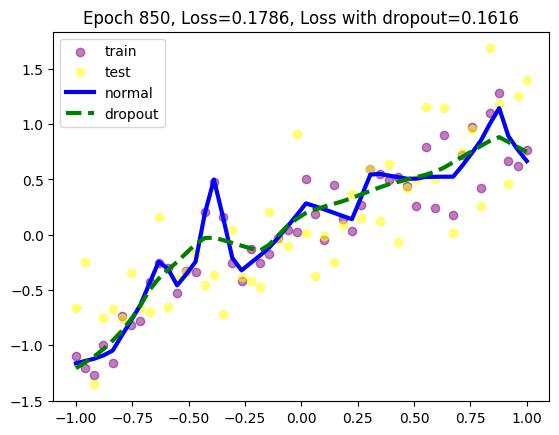

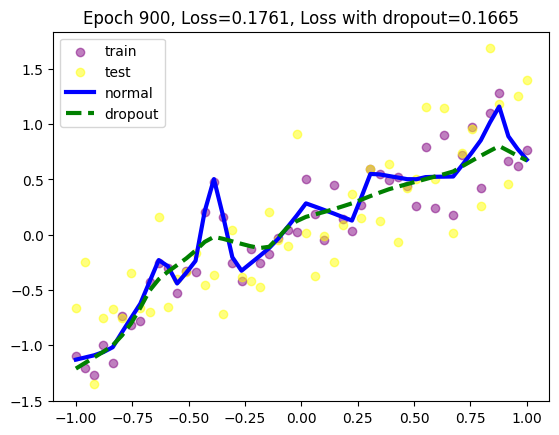

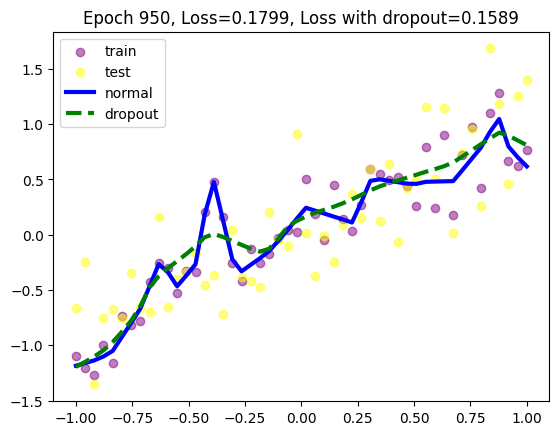

In [22]:
# 모델 학습

max_epochs = 1000
for epoch in range(max_epochs):
  pred = model(x_train)
  loss = loss_fn(pred, y_train)
  opt.zero_grad()
  loss.backward()
  opt.step()

  pred_dropout = model_dropout(x_train)
  loss_dropout = loss_fn(pred_dropout, y_train)
  opt_dropout.zero_grad()
  loss_dropout.backward()
  opt_dropout.step()

  if epoch % 50 ==0:
    model.eval()
    model_dropout.eval()

    test_pred = model(x_test)
    test_loss = loss_fn(test_pred, y_test)

    test_pred_dropout = model_dropout(x_test)
    test_loss_dropout = loss_fn(test_pred_dropout, y_test)

    plt.scatter(x_train.data.numpy(), y_train.data.numpy() , c = 'purple',
                alpha=0.5, label= 'train')
    plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c='yellow',
                alpha=0.5, label='test')
    plt.plot(x_test.data.numpy(), test_pred.data.numpy(), 'b-', lw=3,
             label='normal')

    plt.plot(x_test.data.numpy(), test_pred_dropout.data.numpy(), 'g--', lw=3,
             label='dropout')

    plt.title('Epoch %d, Loss=%0.4f, Loss with dropout=%0.4f' %
              (epoch, test_loss, test_loss_dropout))
    plt.legend()
    model.train()
    model_dropout.train()
    plt.pause(0.05)

전반적으로 오차가 줄어드는 범위는 크지 않다. 하지만 드롭아웃을 적용했을 때의 오차가 더 낮은 것을 확인할 수 있다. 이제 그래프를 자세히 살펴보겠다. 출력 결과에서 초록색 점
선(드롭아웃이 적용된 모댈)과 파란색 실선(드롭아웃이 적용되지 않은 모델)의 차이가 크지 않아 보일 수 있지만 이 정도면 실제로는 큰 차이가 있는 상태이다. 훈련 횟수가 늘어날수록 파란색 실선은 가장자리의 자주색 점들을 찾아가고 있다. 문제는 자쩍 선이 훈련 데이터셋을 의미한다는 것이고， 이것은 다른 의미로 과적합 현상을 보이고 있다는 것이다. 과적합이 발생하는 모델은 훈련 데이터에 대한 정확도는 높을 수 있지만 새로운 데이터， 즉 검증 데이터나 테스트 데이터에 대해서는 제대로 동작하지 않는 문제가 있다. 이와 같이 과적합 현상을 방지하기 위해 드롭아웃을 시용하며 초학객 점선 그래프에서는 과적합 현상이 발생하지 않는 것을 확인할 수 있다.

이제 마지막으로 조기 종료에 대해 알아보겠다.


## 8.3.3 조기 종료를 이용한 성능 최적화

조기 종료는 뉴럴 네트워크가 과적합을 회피하는 규제 기법이다. 훈련 데이터와 별도로 검증 데이터를 준비하고， 매 에포크마다 검증 데이터에 대한 오차(vaJidalÌoD loss)를 측정하
여 모델의 종료 시점을 제어한다. 즉， 과적합이 발생하기 전까지 학습에 대한 오차(training loss)와 검증에 대한 오차 모두 감소하지만， 과적합이 발생하면 훈련 데이터셋에 대한 오차는 감소하는 반면 검증 데이터셋에 대한 오차는 증가한다. 따라서 조기 종료는 검증 데이터셋에 대한 오차가 증가하는 시점에서 학습을 멈추도록 조정한다.

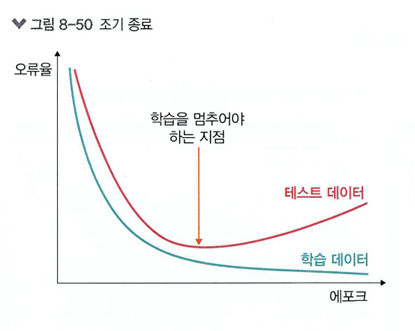

조기 종료는 학습을 언제 종료시킬지 결정할 뿐이지 최고의 성능을 갖는 모델을 보장하지는 않는다는 점에 주의해야 한다. 이번 예제는 조기 종료뿐만 아니라 학습률을 조정해서 성능을 향상시키는 방법애 대해서도 함께 알아본다.


In [23]:
# 라이브러리 호출

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms, datasets

import matplotlib
import matplotlib.pyplot as plt
import time
import argparse
from tqdm import tqdm
matplotlib.style.use('ggplot')
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

앞에서 설정했던 GPU 사용을 위한 코드이다. 최근 높은 GPU 가격 때문에 GPU가 장착되어 있
지 않은 서버/PC가 많을 수 있다. 하지만 걱정할 필요는 없다. 파이토치는 CPU에서도 잘 실행되며 책에서 다루는 예제들도 CPU만으로도 충분히 사용할 수 있도록 구성되어 있다.


```
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
```

다음은 데이터셋 전처리를 위한 항목들을 정의한다. 전처리에는 데이터 크기 조정 및 데이터 정규화(분포 조정) 등이 포함된다.


In [24]:
# 데이터셋 전처리

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

예제에서 사용하는 데이터셋은 핫도그와 핫도그가 아닌 이미지들을 사용한다. 데이터셋은
https://www.kaggle.com/dansbecker/hot-dog-not-hot-dog에서 내려받을 수 있지만
이것 역시 ‘Food 101 dataset'을 이용한 것이다.
참고로 데이터셋에 사용되는 핫도그와 핫도그가 아닌 이미지들은 그림 8-51 그림 8-52와 같다.

In [25]:
!git clone https://github.com/gilbutITbook/080289.git

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 2278 (delta 3), reused 2 (delta 2), pack-reused 2262 (from 2)
Receiving objects: 100% (2278/2278), 330.29 MiB | 30.42 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.


In [26]:
# 데이터셋 가져오기

train_dataset = datasets.ImageFolder(
    root=r'080289/chap08/data/archive/train',
    transform = train_transform
)
train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size = 32, shuffle = True,
)
val_dataset = datasets.ImageFolder(
    root =r'080289/chap08/data/archive/test',
    transform = val_transform
)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size = 32, shuffle = False,
)

이제 모델을 생성할 텐데, 네트워크를 직접 구축하는 것이 아닌 사전 학습된 ResNet50을 사용할 예정이다. 6장에서 배웠듯이 사전 학습된 모댈을 사용할 경우 간편하게 네트워크를 구성하고 사용할 수 있는 장점이 있다.

In [27]:
# 모델 생성

def resnet50(pretrained = True, requires_grad = False):
  model = models.resnet50(progress=True, pretrained=pretrained)
  if requires_grad == False:
    for param in model.parameters():
      param.requires_grad = False
  elif requires_grad == True:
    for param in model.parameters():
      param.requires_grad = True
  model.fc = nn.Linear(2048, 2)
  return model

파이토치에서 조기 종료와 함께 지주 사용되는 것으로 학습률 감소(learning rate decay)라는 것이 있다. 학습률에 대한 값을 고정시켜서 모델을 학습시커는 것이 아니라 학습이 진행되는 과정에서 학습률을 조금씩 낮추어 주는 성능 튜닝 기법 중에 하나이다. 학습률 감소는 학습률 스케줄러(learning rate scheduler)라는 것을 이용하는데, 주어진 'patience' 횟수만큼 검증 데이터셋에 대한 오차 감소가 없으면 역시 주어진 'factor'만큼 학습률을 감소시켜서 모댈 학습의 최적화가 가능하도록 도외준다. 다음 코드를 통해 자세히 살펴보겠다.

In [28]:
# 학습률 감소

class LRScheduler():
  def __init__(
      self, optimizer, patience=5, min_lr=1e-6, factor=0.5
  ):
      self.optimizer = optimizer
      self.patience = patience
      self.min_lr = min_lr
      self.factor = factor
      self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
          self.optimizer,
          mode='min',
          patience=self.patience,
          factor=self.factor,
          min_lr=self.min_lr,
          verbose=True
      )
  def __call__(self, val_loss):
      self.lr_scheduler.step(val_loss)

## 콜백(callback)

개발자가 명시적으로 함수를 호출하는 것이 아니라 개발자는 단지 함수 등록만 하고 특정 이벤트 발생에 의해 함수를 호출하고 처리하도록 하는 것이 콜백 함수이다. 콜백 함수로는 동기적(synchronous) 함수와 비동기적
(asynchronous) 함수가 있다. 동기적 함수는 코드가 위에서 아래로， 왼쪽에서 오른쪽으로 순차적으로 실행되는 함수이며 비동기 함수는 병렬 처리와 같다고 이해하면 된다. 어떤 코드를 실행했을 때 상당한 시간을 기다려야 하는
경우 해당 코드가 완료될 때까지 기다리는 것이 아닌 다른 코드가 먼저 처리되도록 하는 것이 비동기 함수이다.

In [29]:
## 조기 종료

class EarlyStopping():
  def __init__(self, patience = 5, verbose=False, delta=0,
               path = '080289/chap08/data/checkpoint.pt'):
    self.patience = patience # 1
    self.verbose = verbose
    self.coutner = 0
    self.best_score = None # 검증 데이터셋에 대한 오차 최적화 값(오차가 가장 낮은 값)
    self.early_stop = False # 조기 종료를 의미하며 초깃값은 False로 설정
    self.val_loss_min = np.Inf # np.Inf(infinity)는 넘파이에서 무한대를 표현
    self.delta = delta # 2
    self.path = path # 모델이 저장될 경로

  def __call__(self, val_loss, model): # 에포크만큼 학습이 반복되면서 best_loss가 갱신되고, best_loss에 진전이 없으면 조기 종료한 후 모델을 저장
    score = -val_loss
    if self.best_score is None: # best_score에 값이 존재하지 않으면 실행
      self.best_score = score
      self.save_checkpoint(val_loss, model)
    elif score < self.best_score + self.delta: # best_score + delta가 score보다 크면 실행
      self.counter += 1
      print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
      if self.counter >= self.patience:
        self.early_stop = True
    else: # 그 외 모든 경우에 실행
      self.best_score = score
      self.save_checkpoint(val_loss, model)
      self.counter = 0

  def save_checkpoint(self, val_loss, model): # 검증 데이터셋에 대한 오차가 감소하면 모델을 저장
    if self.verbose:
      print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
    torch.save(model.state_dict(), self.path) # 지정된 경로에 모델 저장
    self.val_loss_min = val_loss

1. patience: 오차 개선이 없다고 바로 종료하지 않고 개선이 없는 에포크를 얼마나 기다려 줄지 지정한다.

2. delta: 오차가 개선되고 있다고 판단하기 위한 최소 변화량을 나타낸다. 변화량이 de1ta보다 적다면 개선이 없다고 판단한다.

일반적으로 케라스에서 제공하는 콜백(keras.callbacks)을 이용하면 손쉽게 조기 종료를 구현할 수 있지만 파이토치에서는 조기 종료 함수 자체를 사용자가 직접 구현해야 한다. 이러한 과정이 번거롭다면 케라스를 이용하면 편리하다.

예제는 학습률 감소와 조기 종료 두 개에 대한 성능 튜닝을 진행하고 있다. 즉, 함수에 넘겨주는 인수 값에 따라 다른 동작을 하도록 해야 하는데 이때 시용할 수 있는 것이 argparse 라이브러리다. ArgumentParser()를 이용하여 변수와 타입을 정의해 주고 add_argument()를 이용해서 변수에 인수 값을 하나씩 추가한다. 그리고 마지막으로 parse_args()를 통해 사용자로부터 입력받은 값들을 args 변수에 저장한다.

In [30]:
# 인수 값 지정

parser = argparse.ArgumentParser() # 인수 값을 받을 수 있는 인스턴스 생성
parser.add_argument('--lr-scheduler', dest = 'lr_scheduler', action = 'store_true') # 1
parser.add_argument('--early-stopping', dest = 'early_stopping', action = 'store_true') # 조기 종료에 대한 인수
args, unknown = parser.parse_known_args() # 2
args = vars(args)

1. 원하는 인수 값을 추가한다. 이때 parser.add_argumet()는 인수 개수만큼 만들어 준다.

2. 입력받은 인수 값이 실제로 args 변수에 저장된다.

In [31]:
print(f"Computation device: {device}\n") # CPU를 사용하는지 GPU를 사용하는지 검사
model = models.resnet50(pretrained=True).to(device) # 사전 훈련된 ResNet50 사용
total_params = sum(p.numel() for p in model.parameters()) # 총 파라미터 수
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad) # 학습 가능한 파라미터 수
print(f"{total_trainable_params:,} training parameters.")

Computation device: cuda:0



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]


25,557,032 total parameters.
25,557,032 training parameters.


전체 파라미터와 학습 가능한 파라미터는 25,557,0327R라는 것을 보여준다.

초기 학습률, 에포크 및 옵티마이저와 손실 함수를 지정한다.

In [32]:
# 옵티마이저와 손실 함수 지정

lr = 0.001
epochs = 100
optimizer = optim.Adam(model.parameters(), lr = lr)
criterion = nn.CrossEntropyLoss()

'--lr-scheduler' 또는 '--early-stopping' 처럼 어 떤 인수도 사용하지 않을 때 오차, 정확도 및 모델의 이름으로 사용할 문자열을 지정한다.

In [33]:
# 오차, 정확도 및 모델의 이름에 대한 문자열

loss_plot_name = 'loss' # 오차 출력에 대한 문자열
acc_plot_name = 'accuracy' # 정확도 출력에 대한 문자열
model_name = 'model' # 모델을 저장하기 위한 문자열

'--lr-scheduler' 또는 '--early-stopping' 인수를 사용할 경우 오차, 정확도 및 모델의 이름으로 사용할 문자열을 지정한다.

In [34]:
# 오차, 정확도 및 모델의 이름에 대한 문자열

if args['lr_scheduler']:
  print('INFO: Initializing learning rate scheduler')
  lr_scheduler = LRScheduler(optimizer)
  loss_plot_name = 'lrs_loss' # 학습률 감소를 적용했을 때의 오차에 대한 문자열
  acc_plt_name = 'lrs_accuracy' # 학습률 감소를 적용했을 때의 정확도에 대한 문자열
  model_name = 'lrs_model' # 학습률 감소를 적용했을 때의 모델에 대한 문자열
if args['early_stopping']:
  print('INFO: Initializing early stopping')
  early_stopping = EarlyStopping()
  loss_plot_name = 'es_loss' # 조기 종료를 적용했을 때의 오차에 대한 문자열
  acc_plot_name = 'es_accuracy' # 조기 종료를 적용했을 때의 정확도에 대한 문자열
  model_name = 'es_model' # 조기 종료를 적용했을 때의 모델에 대한 문자열

In [35]:
# 모델 학습 함수

def training(model, train_dataloader, train_dataset, optimizer, criterion):
  print('Training')
  model.train()
  train_running_loss = 0.0
  train_running_correct = 0
  counter = 0
  total = 0
  prog_bar = tqdm(enumerate(train_dataloader), total = int(len(train_dataset)/
                                                           train_dataloader.batch_size)) # 훈련 진행 과정을 시각적으로 표현
  for i, data in prog_bar:
    counter += 1
    data, target = data[0].to(device), data[1].to(device)
    total += target.size(0)
    optimizer.zero_grad()
    outputs = model(data)
    loss = criterion(outputs, target)
    train_running_loss += loss.item()
    _, preds = torch.max(outputs.data, 1)
    train_running_correct += (preds == target).sum().item()
    loss.backward()
    optimizer.step()

  train_loss = train_running_loss / counter
  train_accuracy = 100. * train_running_correct / total
  return train_loss, train_accuracy

In [36]:
# 모델 검증 함수

def validate(model, test_dataloader, val_dataset, criterion):
  print('Validating')
  model.eval()
  val_running_loss = 0.0
  val_running_correct = 0
  counter = 0
  total = 0
  prog_bar = tqdm(enumerate(test_dataloader), total=int(len(val_dataset)/
                                                        test_dataloader.batch_size)) # 모델 검증 과정을 시각적으로 표현
  with torch.no_grad():
    for i, data in prog_bar:
      counter += 1
      data, target = data[0].to(device), data[1].to(device)
      total += target.size(0)
      outputs = model(data)
      loss = criterion(outputs, target)

      val_running_loss += loss.item()
      _, preds = torch.max(outputs.data, 1)
      val_running_correct += (preds == target).sum().item()

    val_loss = val_running_loss / counter
    val_accuracy = 100. * val_running_correct / total
    return val_loss, val_accuracy

In [37]:
# 모델 학습

train_loss, train_accuracy = [], [] # 훈련 데이터셋을 이용한 모델 학습 결과(오차, 정확도)를 저장하기 위한 변수(리스트 형태를 갖는다)
val_loss, val_accuracy = [], [] # 검증 데이터셋을 이용한 모델 성능 결과(오차, 정확도)를 저장하기 위한 변수(리스트 형태를 갖는다)

start = time.time()
for epoch in range(epochs):
  print(f"Epoch {epoch+1} of {epochs}")
  train_epoch_loss, train_epoch_accuracy = training(
      model, train_dataloader, train_dataset, optimizer, criterion
  )
  val_epoch_loss, val_epoch_accuracy = validate(
      model, val_dataloader, val_dataset, criterion
  )
  train_loss.append(train_epoch_loss)
  train_accuracy.append(train_epoch_accuracy)
  val_loss.append(val_epoch_loss)
  val_accuracy.append(val_epoch_accuracy)
  if args['lr_scheduler']: # 인수 값이 lr_scheduler이면 다음을 실행
    lr_scheduler(val_epoch_loss)
  if args['early_stopping']: # 인수 값이 early_stopping이면 다음을 실행
    early_stopping(val_epoch_loss, model)
    if early_stopping.early_stop:
      break
  print(f"Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_accuracy:.2f}")
  print(f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.2f}")
  end = time.time()
  print(f"Training time: {(end-start)/60:.3f} minutes")

Epoch 1 of 100
Training


16it [00:06,  2.59it/s]


Validating


16it [00:03,  4.13it/s]


Train Loss: 2.1253, Train Acc: 60.44
Val Loss: 12.9385, Val Acc: 52.00
Training time: 0.168 minutes
Epoch 2 of 100
Training


...

Train Loss: 0.1546, Train Acc: 95.18
Val Loss: 1.2490, Val Acc: 69.80
Training time: 14.985 minutes
Epoch 100 of 100
Training


16it [00:05,  3.03it/s]


Validating


16it [00:04,  3.86it/s]

Train Loss: 0.1395, Train Acc: 95.58
Val Loss: 1.0329, Val Acc: 71.20
Training time: 15.142 minutes


CPU를 이용하여 에포크 100을 수행할 경우 약 11시간 정도의 시간이 펼요함을 보여 준다. 따 라서 빠른 학습을 원한다면 GPU 환경에서 학습을 진행하는 것이 좋다. 여건이 안 되면 코랩에서
GPU로 런타임을 설정하고 실행한다.

마지막으로 모댈의 정확도와 오치를 그래프를 통해서 확인해 보겠다. 이때 출력 결과는 어떤
인수도 사용되는 않는 모델의 학습 결과다.

Saving loss and accuracy plots...


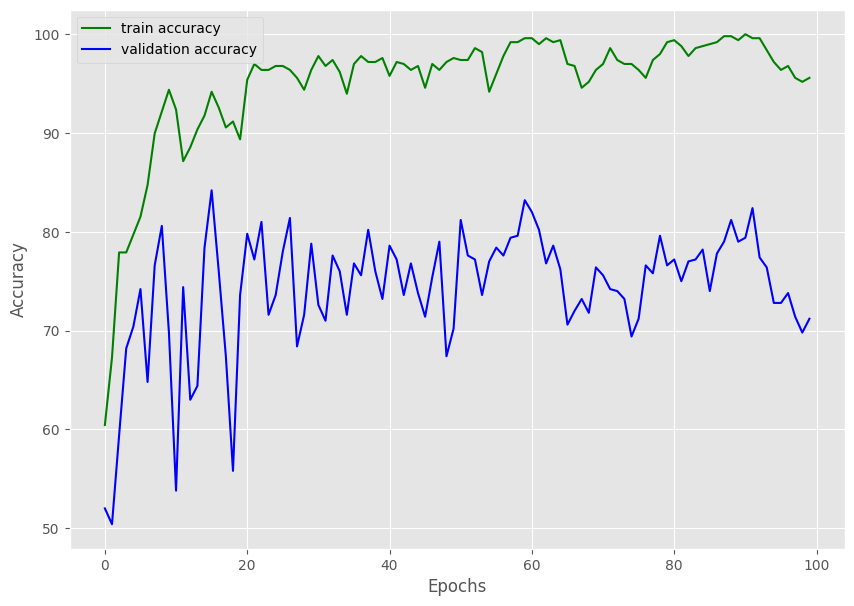

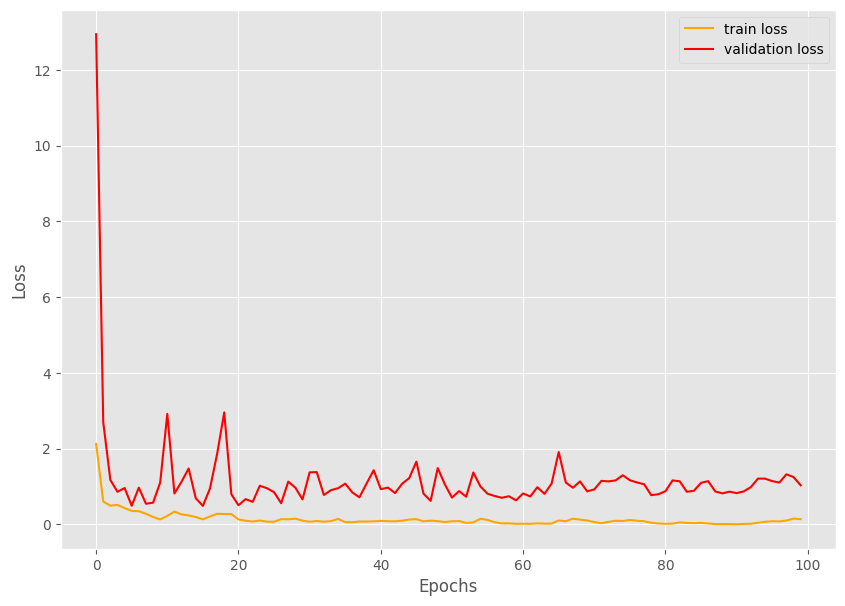

Saving model...
TRAINING COMPLETE


In [38]:
# 모델 학습 결과 출력

print('Saving loss and accuracy plots...')
plt.figure(figsize = (10, 7))
plt.plot(train_accuracy, color = 'green', label = 'train accuracy') # 훈련 데이터셋에 대한 정확도를 그래프로 출력
plt.plot(val_accuracy, color = 'blue', label = 'validation accuracy') # 검증 데이터셋에 대한 정확도를 그래프로 출력
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f'080289/chap08/data/{acc_plot_name}.png')
plt.show()
plt.figure(figsize = (10, 7))
plt.plot(train_loss, color = 'orange', label = 'train loss') # 훈련 데이터셋에 대한 오차를 그래프로 출력
plt.plot(val_loss, color = 'red', label = 'validation loss') # 검증 데이터셋에 대한 오차를 그래프로 출력
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f'080289/chap08/data/{loss_plot_name}.png')
plt.show()

print('Saving model...')
torch.save(model.state_dict(), f'080289/chap08/data/{model_name}.pt') # 모델을 저장
print('TRAINING COMPLETE')

정확도의 경우 위아래로 많은 변동이 있는 것을 볼 수 있다. 정확도가 10% 이상 차이가 나는 일부 에포크 사이는 기복이 매우 심하다. 오차에 대한 그래프도 크게 다르지 않다. 특히 에포크 10 이후부터 검증 데이터셋에 대한 오차가 미세한 차이로 우상향하는 것을 볼 수 있다. 이것은 모델이 과적합되기 시작했으며 적절한 훈련을 계속하려면 학습률 값을 줄여야 한다는 것을 보여준다.

명심해야 할 것은 조기 종료가 항상 성능에 좋은 영향을 미치는 것은 아니다. 조기 종료로 인해 모벨이 제대로 학습하지 못할 수 있다. 실제로 검증 데이터셋에 대한 정확도 그래프가 위아래로 오가면서 불안정한 결과를 출력하고 있다. 그렇다고 학습을 계속 이어 간다고 해서 더 좋은 결과를 얻을 수 있다는 보장도 없다. 따라서 그래프가 의미하는 내용을 잘 이해하고 적절한 성능 향상 방안을 적용하는 것이 중요하다. 앞에서 검증 데이터셋에 대한 정확도는 좋지 않지만, 오차는 많이 낮아진 것을 확인할 수 있다. 따라서 정확도만 보고 조기 종료가 효과가 없다고 판단하기에는 숲이 아닌 나무만 보고 판단한 결과와 같다.

분명한 것은 학습률 스케줄러를 이용한 학습률 조정 기법과 조기 종료가 모델 성능을 향상시키는 데는 도움이 된다는 것이다. 단 모든 모댈에 일괄적으로 적용하는 것이 아닌, 기존의 출력된 그래프를 해석해서 어떤 성능 기법을 적용할지 결정하는 것이 중요하다.